In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/gurgaon_properties_missing_value_imputation.csv")

In [ ]:
df.shape

(1528, 18)

In [ ]:
df['floorNum'] = df['floorNum'].replace('G','0')
df['floorNum'] = df['floorNum'].replace('L','-1')

In [ ]:
df['floorNum'] = df['floorNum'].astype('int')

In [ ]:
df.head()

,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,godrej meridien,Sector 106,2.85,15364.0,3,3,3,8,East,Relatively New,1653.00,1,1,0,1,1,Unknown,5
1,experion windchants,Sector 112,6.25,16609.0,3,5,3,6,North,Moderately Old,2873.18,0,1,0,0,0,Semi-Furnished,0
2,godrej 101,Sector 79,3.50,16471.0,3,3,3,11,North,Under Construction,1603.00,0,1,0,0,0,Unknown,0
3,dlf new town heights 1,Sector 90,2.85,10451.0,4,4,3+,4,North-West,Moderately Old,2725.00,0,1,0,1,0,Semi-Furnished,21
4,experion windchants,Sector 112,8.40,17327.0,4,6,3+,6,West,Moderately Old,3655.35,0,1,0,0,0,Unknown,0


In [ ]:
train_df = df.drop(columns=['society','price_per_sqft'])

In [ ]:
train_df

,sector,price,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,Sector 106,2.85,3,3,3,8,East,Relatively New,1653.00,1,1,0,1,1,Unknown,5
1,Sector 112,6.25,3,5,3,6,North,Moderately Old,2873.18,0,1,0,0,0,Semi-Furnished,0
2,Sector 79,3.50,3,3,3,11,North,Under Construction,1603.00,0,1,0,0,0,Unknown,0
3,Sector 90,2.85,4,4,3+,4,North-West,Moderately Old,2725.00,0,1,0,1,0,Semi-Furnished,21
4,Sector 112,8.40,4,6,3+,6,West,Moderately Old,3655.35,0,1,0,0,0,Unknown,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1523,Sector 76,0.85,2,2,3,14,West,Relatively New,834.00,0,0,0,0,1,Unknown,3
1524,Sector 69,2.30,3,3,2,10,South,New Property,1470.00,0,0,0,1,0,Semi-Furnished,19
1525,Sector 70,3.22,4,5,3+,8,East,Moderately Old,2150.00,0,1,0,0,0,Furnished,18
1526,Sector 66,2.90,4,4,3+,9,West,Moderately Old,1711.00,0,1,0,0,0,Semi-Furnished,25


<Axes: >

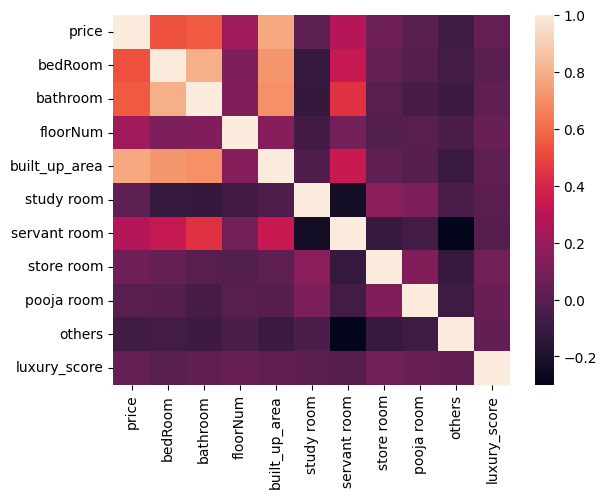

In [ ]:
sns.heatmap(train_df.select_dtypes('number').corr())

In [ ]:
train_df.select_dtypes('number').corr()['price'].sort_values(ascending=False)

,price
price,1.000000
built_up_area,0.775553
bathroom,0.552065
bedRoom,0.525331
servant room,0.281335
floorNum,0.214435
store room,0.068897
luxury_score,0.041701
study room,0.019407
pooja room,0.003321


In [ ]:
# cols in question

# numerical -> luxury_score, others
# categorical -> sector, agePossession, furnishing_type

In [ ]:
df[df['luxury_score'] == 0].shape

(549, 18)

In [ ]:
df[df['furnishing_type'] == 'Furnished']

,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
22,parsvnath exotica,Sector 53,13.50,28939.0,5,6,3+,9,North,Moderately Old,4000.0,0,1,0,1,0,Furnished,21
43,dlf the primus,Sector 82A,2.85,15677.0,3,4,3+,25,East,Moderately Old,1495.0,0,1,0,0,0,Furnished,0
48,ireo the corridors,Sector 67A,3.19,17225.0,3,4,2,6,East,New Property,1443.0,0,1,0,0,0,Furnished,6
54,dlf park place,Sector 54,6.71,33838.0,3,4,3+,15,West,Moderately Old,1500.0,0,1,0,0,0,Furnished,22
91,sobha city,Sector 108,4.95,21127.0,4,5,3,16,North-East,New Property,1913.0,1,1,0,1,1,Furnished,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1453,unitech harmony,Nirvana Country,3.55,13498.0,3,4,2,11,East,Moderately Old,2620.0,0,1,0,1,1,Furnished,25
1456,pioneer park,Sector 61,5.00,19608.0,4,4,3+,8,North-East,Moderately Old,2016.0,1,1,0,0,0,Furnished,9
1473,unitech fresco,Nirvana Country,2.60,13852.0,3,4,3+,16,North-East,Moderately Old,1848.0,0,1,0,0,0,Furnished,20
1521,tata primanti,Sector 72,5.15,17728.0,4,5,3+,39,North-East,New Property,2500.0,0,1,0,0,0,Furnished,25


In [ ]:
train_df = train_df.drop(columns=['furnishing_type','luxury_score'],axis=1)

In [ ]:
train_df.head()

,sector,price,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others
0,Sector 106,2.85,3,3,3,8,East,Relatively New,1653.00,1,1,0,1,1
1,Sector 112,6.25,3,5,3,6,North,Moderately Old,2873.18,0,1,0,0,0
2,Sector 79,3.50,3,3,3,11,North,Under Construction,1603.00,0,1,0,0,0
3,Sector 90,2.85,4,4,3+,4,North-West,Moderately Old,2725.00,0,1,0,1,0
4,Sector 112,8.40,4,6,3+,6,West,Moderately Old,3655.35,0,1,0,0,0


# floorNum

<Axes: ylabel='floorNum'>

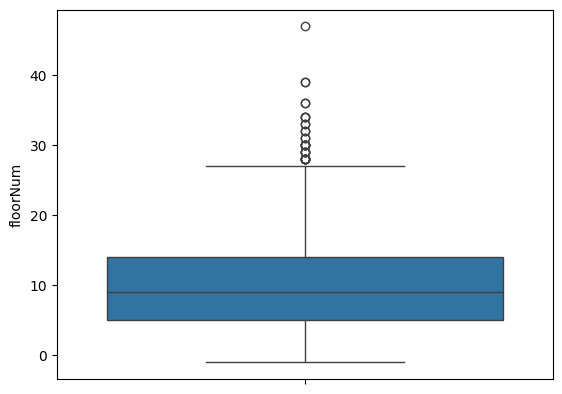

In [ ]:
sns.boxplot(df['floorNum'])

In [ ]:
def categorize_floor(floor):
    if -1 <= floor <= 2:
        return "Low Floor"
    elif 3 <= floor <= 10:
        return "Mid Floor"
    elif 11 <= floor <= 51:
        return "High Floor"
    else:
        return None  # or "Undefined" or any other label for floors outside the defined bins

In [ ]:
train_df['floor_category'] = train_df['floorNum'].apply(categorize_floor)

In [ ]:
train_df = train_df.drop('floorNum',axis=1)

In [ ]:
train_df.head()

,sector,price,bedRoom,bathroom,balcony,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,floor_category
0,Sector 106,2.85,3,3,3,East,Relatively New,1653.00,1,1,0,1,1,Mid Floor
1,Sector 112,6.25,3,5,3,North,Moderately Old,2873.18,0,1,0,0,0,Mid Floor
2,Sector 79,3.50,3,3,3,North,Under Construction,1603.00,0,1,0,0,0,High Floor
3,Sector 90,2.85,4,4,3+,North-West,Moderately Old,2725.00,0,1,0,1,0,Mid Floor
4,Sector 112,8.40,4,6,3+,West,Moderately Old,3655.35,0,1,0,0,0,Mid Floor


In [ ]:
train_df.to_csv("gurgaon_properties_post_feature_selection_v2.csv",index=False)

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

# Create a copy of the original data for label encoding
data_label_encoded = train_df.copy()

categorical_cols = train_df.select_dtypes(include=['object']).columns

# Apply label encoding to categorical columns
for col in categorical_cols:
    oe = OrdinalEncoder()
    data_label_encoded[col] = oe.fit_transform(data_label_encoded[[col]])
    print(oe.categories_)

[array(['Block T Sector-109 ', 'DLF Phase 2', 'DLF Phase 4', 'DLF Phase 5',
       'Dwarka Expressway ', 'Golf Course Road', 'Gwal Pahari',
       'Hans Enclave', 'Hayatpur', 'MG Road', 'Malibu Town',
       'Nangli Umarpur', 'Nirvana Country', 'Palam Vihar',
       'Pocket H Nirvana Country', 'Pocket I Nirvana Country',
       'Sector 1 Imt Manesar', 'Sector 102 ', 'Sector 103 ',
       'Sector 104 ', 'Sector 106 ', 'Sector 107 ', 'Sector 108 ',
       'Sector 109 ', 'Sector 110 ', 'Sector 110 A ', 'Sector 111 ',
       'Sector 112 ', 'Sector 113  ', 'Sector 1A IMT Manesar',
       'Sector 3 ', 'Sector 30 ', 'Sector 36 Sohna', 'Sector 36A ',
       'Sector 37C ', 'Sector 37D ', 'Sector 42 ', 'Sector 43 ',
       'Sector 45 ', 'Sector 47 ', 'Sector 48 ', 'Sector 49 ',
       'Sector 52 ', 'Sector 53 ', 'Sector 54 ', 'Sector 55 ',
       'Sector 56 ', 'Sector 57 ', 'Sector 59 ', 'Sector 60 ',
       'Sector 61 ', 'Sector 62 ', 'Sector 63 ', 'Sector 63A ',
       'Sector 65 ', 'Sector 66

In [ ]:
# Splitting the dataset into training and testing sets
X_label = data_label_encoded.drop('price', axis=1)
y_label = data_label_encoded['price']

In [ ]:
X_label

,sector,bedRoom,bathroom,balcony,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,floor_category
0,20.0,3,3,3.0,0.0,3.0,1653.00,1,1,0,1,1,2.0
1,27.0,3,5,3.0,1.0,0.0,2873.18,0,1,0,0,0,2.0
2,66.0,3,3,3.0,1.0,4.0,1603.00,0,1,0,0,0,0.0
3,78.0,4,4,4.0,3.0,0.0,2725.00,0,1,0,1,0,2.0
4,27.0,4,6,4.0,7.0,0.0,3655.35,0,1,0,0,0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1523,64.0,2,2,3.0,7.0,3.0,834.00,0,0,0,0,1,0.0
1524,59.0,3,3,2.0,4.0,1.0,1470.00,0,0,0,1,0,2.0
1525,60.0,4,5,4.0,0.0,0.0,2150.00,0,1,0,0,0,2.0
1526,55.0,4,4,4.0,7.0,0.0,1711.00,0,1,0,0,0,2.0


In [ ]:
y_label

,price
0,2.85
1,6.25
2,3.50
3,2.85
4,8.40
...,...
1523,0.85
1524,2.30
1525,3.22
1526,2.90


# Technique 1 - Correlation Analysis

<Axes: >

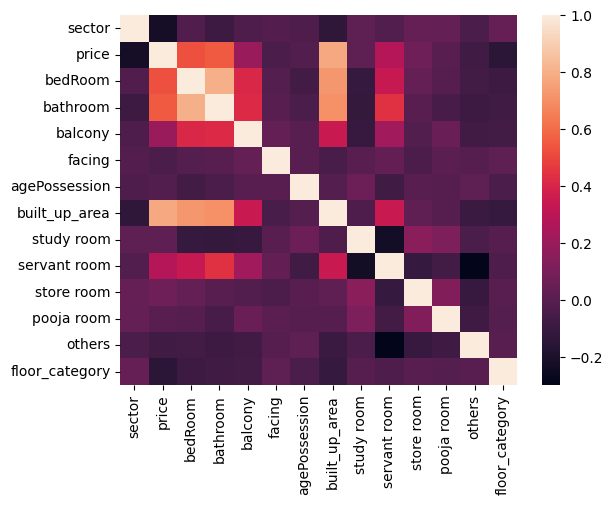

In [ ]:
sns.heatmap(data_label_encoded.corr())

In [ ]:
fi_df1 = data_label_encoded.corr()['price'].iloc[1:].to_frame().reset_index().rename(columns={'index':'feature','price':'corr_coeff'})
fi_df1

,feature,corr_coeff
0,price,1.000000
1,bedRoom,0.525331
2,bathroom,0.552065
3,balcony,0.198878
4,facing,-0.041581
5,agePossession,-0.020299
6,built_up_area,0.775553
7,study room,0.019407
8,servant room,0.281335
9,store room,0.068897


# Technique 2 - Random Forest Feature Importance

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_label, y_label)

# Extract feature importance scores for label encoded data
fi_df2 = pd.DataFrame({
    'feature': X_label.columns,
    'rf_importance': rf_label.feature_importances_
}).sort_values(by='rf_importance', ascending=False)

fi_df2

,feature,rf_importance
6,built_up_area,0.686155
0,sector,0.213017
5,agePossession,0.015551
2,bathroom,0.015515
3,balcony,0.014707
4,facing,0.012271
1,bedRoom,0.012206
12,floor_category,0.009365
9,store room,0.005759
10,pooja room,0.004967


# Technique 3 - Gradient Boosting Feature importances

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

# Train a Random Forest regressor on label encoded data
gb_label = GradientBoostingRegressor()
gb_label.fit(X_label, y_label)

# Extract feature importance scores for label encoded data
fi_df3 = pd.DataFrame({
    'feature': X_label.columns,
    'gb_importance': gb_label.feature_importances_
}).sort_values(by='gb_importance', ascending=False)

fi_df3

,feature,gb_importance
6,built_up_area,0.706288
0,sector,0.250622
2,bathroom,0.012131
3,balcony,0.006684
12,floor_category,0.006136
5,agePossession,0.005901
1,bedRoom,0.005266
8,servant room,0.002456
9,store room,0.002211
10,pooja room,0.000955


# Technique 4 - Permutation Importance

In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X_train_label, X_test_label, y_train_label, y_test_label = train_test_split(X_label, y_label, test_size=0.2, random_state=42)

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_train_label, y_train_label)

# Calculate Permutation Importance
perm_importance = permutation_importance(rf_label, X_test_label, y_test_label, n_repeats=30, random_state=42)

# Organize results into a DataFrame
fi_df4 = pd.DataFrame({
    'feature': X_label.columns,
    'permutation_importance': perm_importance.importances_mean
}).sort_values(by='permutation_importance', ascending=False)

fi_df4

,feature,permutation_importance
6,built_up_area,1.074154
0,sector,0.414859
3,balcony,0.010811
1,bedRoom,0.008976
12,floor_category,0.006883
5,agePossession,0.005854
2,bathroom,0.004505
8,servant room,0.004160
9,store room,0.003184
4,facing,0.002083


# Technique 5 - LASSO

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_label)

# Train a LASSO regression model
# We'll use a relatively small value for alpha (the regularization strength) for demonstration purposes
lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_scaled, y_label)

# Extract coefficients
fi_df5 = pd.DataFrame({
    'feature': X_label.columns,
    'lasso_coeff': lasso.coef_
}).sort_values(by='lasso_coeff', ascending=False)

fi_df5

,feature,lasso_coeff
6,built_up_area,1.660311
2,bathroom,0.131017
9,store room,0.108356
8,servant room,0.076752
7,study room,0.075111
10,pooja room,0.013347
11,others,0.000609
4,facing,-0.002125
5,agePossession,-0.025326
12,floor_category,-0.119913


# Technique 6 - RFE

In [ ]:
from sklearn.feature_selection import RFE

# Initialize the base estimator
estimator = RandomForestRegressor()

# Apply RFE on the label-encoded and standardized training data
selector_label = RFE(estimator, n_features_to_select=X_label.shape[1], step=1)
selector_label = selector_label.fit(X_label, y_label)

# Get the selected features based on RFE
selected_features = X_label.columns[selector_label.support_]

# Extract the coefficients for the selected features from the underlying linear regression model
selected_coefficients = selector_label.estimator_.feature_importances_

# Organize the results into a DataFrame
fi_df6 = pd.DataFrame({
    'feature': selected_features,
    'rfe_score': selected_coefficients
}).sort_values(by='rfe_score', ascending=False)

fi_df6

,feature,rfe_score
6,built_up_area,0.683141
0,sector,0.219966
5,agePossession,0.016330
3,balcony,0.013886
2,bathroom,0.013802
4,facing,0.011981
1,bedRoom,0.011699
12,floor_category,0.009151
10,pooja room,0.005205
9,store room,0.004815


# Technique 7 - Linear Regression Weights

In [ ]:
from sklearn.linear_model import LinearRegression

# Train a linear regression model on the label-encoded and standardized training data
lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y_label)

# Extract coefficients
fi_df7 = pd.DataFrame({
    'feature': X_label.columns,
    'reg_coeffs': lin_reg.coef_
}).sort_values(by='reg_coeffs', ascending=False)

fi_df7

,feature,reg_coeffs
6,built_up_area,1.681517
2,bathroom,0.174047
9,store room,0.120711
8,servant room,0.092539
7,study room,0.084713
10,pooja room,0.025957
11,others,0.019065
4,facing,-0.011244
5,agePossession,-0.037366
12,floor_category,-0.129473


# Technique 8 - SHAP

In [ ]:
!pip install shap

In [ ]:
import shap

# Compute SHAP values using the trained Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_label, y_label)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_label)

# Summing the absolute SHAP values across all samples to get an overall measure of feature importance
shap_sum = np.abs(shap_values).mean(axis=0)

shap_values

array([[ 1.25864650e-01, -2.70330550e-03, -2.55700381e-02, ...,
        -7.31923755e-03,  1.27738429e-02, -4.38286002e-02],
       [-3.50907966e-01,  8.86668835e-02,  1.01721031e-01, ...,
        -2.16059119e-02,  3.96508030e-03,  5.59831694e-04],
       [-2.47908115e-01, -5.16891757e-03,  1.35461923e-03, ...,
         8.69537772e-03,  2.40578475e-02,  5.13221924e-02],
       ...,
       [-1.89840065e-01,  1.45434243e-02,  3.15349582e-02, ...,
        -3.04555627e-03,  7.86411341e-04, -1.19056455e-01],
       [ 5.41080344e-01,  1.80052834e-02,  7.47608652e-02, ...,
         3.28882544e-03,  1.48811298e-03, -8.06445519e-02],
       [-1.39003980e-01, -9.60814512e-02, -1.90064791e-01, ...,
         5.68616361e-05, -1.30654548e-03, -1.88507565e-02]])

In [ ]:
fi_df8 = pd.DataFrame({
    'feature': X_label.columns,
    'SHAP_score': np.abs(shap_values).mean(axis=0)
}).sort_values(by='SHAP_score', ascending=False)

fi_df8

,feature,SHAP_score
6,built_up_area,1.098503
0,sector,0.591591
12,floor_category,0.057216
2,bathroom,0.040428
5,agePossession,0.034484
8,servant room,0.033886
3,balcony,0.033871
1,bedRoom,0.024463
4,facing,0.021561
9,store room,0.015861


In [ ]:
final_fi_df = fi_df1.merge(fi_df2,on='feature').merge(fi_df3,on='feature').merge(fi_df4,on='feature').merge(fi_df5,on='feature').merge(fi_df6,on='feature').merge(fi_df7,on='feature').merge(fi_df8,on='feature').set_index('feature')

In [ ]:
final_fi_df

,corr_coeff,rf_importance,gb_importance,permutation_importance,lasso_coeff,rfe_score,reg_coeffs,SHAP_score
feature,,,,,,,,
bedRoom,0.525331,0.012206,0.005263,0.008976,-0.121586,0.011699,-0.181472,0.024463
bathroom,0.552065,0.015515,0.012271,0.004505,0.131017,0.013802,0.174047,0.040428
balcony,0.198878,0.014707,0.006686,0.010811,-0.149575,0.013886,-0.162090,0.033871
facing,-0.041581,0.012271,0.000800,0.002083,-0.002125,0.011981,-0.011244,0.021561
agePossession,-0.020299,0.015551,0.005835,0.005854,-0.025326,0.016330,-0.037366,0.034484
built_up_area,0.775553,0.686155,0.706200,1.074154,1.660311,0.683141,1.681517,1.098503
study room,0.019407,0.003811,0.000634,0.000434,0.075111,0.003397,0.084713,0.006915
servant room,0.281335,0.004368,0.002486,0.004160,0.076752,0.004511,0.092539,0.033886
store room,0.068897,0.005759,0.002209,0.003184,0.108356,0.004815,0.120711,0.015861


In [ ]:
# normalize the score
final_fi_df = final_fi_df.divide(final_fi_df.sum(axis=0), axis=1)

In [ ]:
final_fi_df[['rf_importance','gb_importance','permutation_importance','rfe_score','SHAP_score']].mean(axis=1).sort_values(ascending=False)

,0
feature,
built_up_area,0.888049
bathroom,0.017396
balcony,0.015900
floor_category,0.015852
agePossession,0.015719
bedRoom,0.012638
facing,0.009889
servant room,0.008565
store room,0.006145


In [ ]:
# to drop pooja room, study room, others
X_label

,sector,bedRoom,bathroom,balcony,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,floor_category
0,20.0,3,3,3.0,0.0,3.0,1653.00,1,1,0,1,1,2.0
1,27.0,3,5,3.0,1.0,0.0,2873.18,0,1,0,0,0,2.0
2,66.0,3,3,3.0,1.0,4.0,1603.00,0,1,0,0,0,0.0
3,78.0,4,4,4.0,3.0,0.0,2725.00,0,1,0,1,0,2.0
4,27.0,4,6,4.0,7.0,0.0,3655.35,0,1,0,0,0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1523,64.0,2,2,3.0,7.0,3.0,834.00,0,0,0,0,1,0.0
1524,59.0,3,3,2.0,4.0,1.0,1470.00,0,0,0,1,0,2.0
1525,60.0,4,5,4.0,0.0,0.0,2150.00,0,1,0,0,0,2.0
1526,55.0,4,4,4.0,7.0,0.0,1711.00,0,1,0,0,0,2.0


In [ ]:
# with all the cols
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label, y_label, cv=5, scoring='r2')

In [ ]:
scores.mean()

np.float64(0.8122730092178003)

In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label.drop(columns=['pooja room', 'study room', 'others']), y_label, cv=5, scoring='r2')

In [ ]:
scores.mean()

np.float64(0.8167089206614468)

In [ ]:
export_df = X_label.drop(columns=['pooja room', 'study room', 'others'])
export_df['price'] = y_label

In [ ]:
export_df.to_csv('gurgaon_properties_post_feature_selection.csv', index=False)

In [ ]:
export_df.head()

,sector,bedRoom,bathroom,balcony,facing,agePossession,built_up_area,servant room,store room,floor_category,price
0,20.0,3,3,3.0,0.0,3.0,1653.00,1,0,2.0,2.85
1,27.0,3,5,3.0,1.0,0.0,2873.18,1,0,2.0,6.25
2,66.0,3,3,3.0,1.0,4.0,1603.00,1,0,0.0,3.50
3,78.0,4,4,4.0,3.0,0.0,2725.00,1,0,2.0,2.85
4,27.0,4,6,4.0,7.0,0.0,3655.35,1,0,2.0,8.40
